## 6.1 양자 해밀토니안 시뮬레이션 (Quantum Hamiltonian Simulation)

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import StatevectorSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

In [2]:
# 해밀토니안 파라미터 정의
theta = np.pi / 4  # 회전 각도
time = 1  # 시간 진화
steps = 10  # Trotter화 스텝 수

In [3]:
# 큐비트 1개 + 고전 비트 1개로 양자 회로 초기화
qc = QuantumCircuit(1, 1)

In [4]:
# Trotter화로 해밀토니안 진화 정의
for _ in range(steps):
    qc.rx(2 * theta * time / steps, 0)  # x축 회전 적용
    qc.rz(2 * theta * time / steps, 0)  # z축 회전 적용

In [5]:
# 큐비트 측정
qc.measure(0, 0)

Quantum Circuit before compilation:


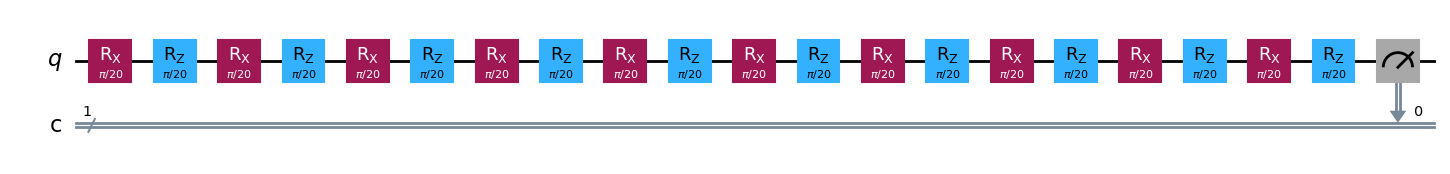

In [6]:
# 컴파일 전 양자 회로 그리기
print("Quantum Circuit before compilation:")
qc.draw('mpl')
plt.show()

In [7]:
# StatevectorSimulator 선택
simulator = StatevectorSimulator()

In [8]:
# 시뮬레이터용으로 회로 트랜스파일
compiled_circuit = transpile(qc, simulator)


Quantum Circuit after compilation:


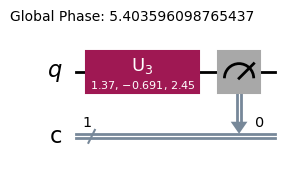

In [9]:
# 컴파일 후 양자 회로 그리기
print("\nQuantum Circuit after compilation:")
compiled_circuit.draw('mpl')
plt.show()

In [10]:
# 회로 시뮬레이션
result = simulator.run(compiled_circuit, shots=1000).result()

In [11]:
# 상태벡터와 카운트 추출
statevector = result.get_statevector()
counts = result.get_counts()

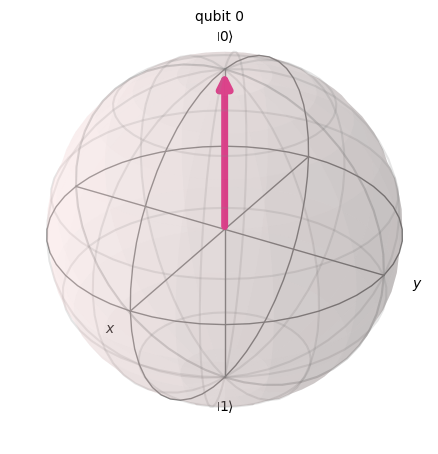

In [12]:
# 상태벡터가 있으면 블로흐 구 그리기
plot_bloch_multivector(statevector)
plt.show()

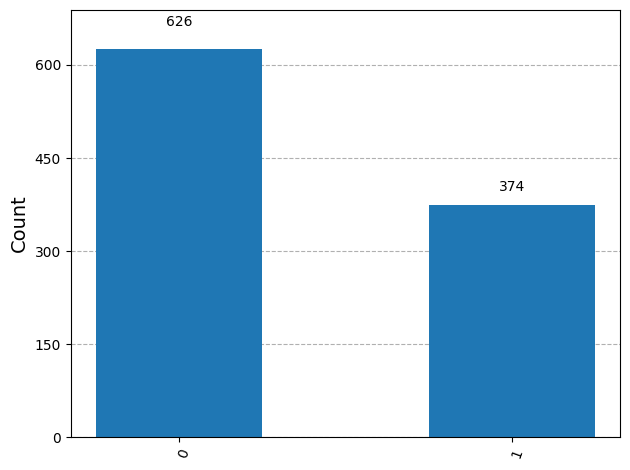

In [13]:
# 측정 결과 히스토그램 그리기
plot_histogram(counts)
plt.show()